In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
class CancerDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.images = []
        self.labels = []
        self.transform = transform

        for patient in os.listdir(root_dir):
            patient_path = os.path.join(root_dir, patient)
            if not os.path.isdir(patient_path):
                continue

            for label in ['0', '1']:
                class_path = os.path.join(patient_path, label)
                if not os.path.exists(class_path):
                    continue

                for img in os.listdir(class_path):
                    self.images.append(os.path.join(class_path, img))
                    self.labels.append(int(label))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
path='/content/drive/MyDrive/data CV/cancer_data_set.zip'
zip_object=zipfile.ZipFile(file=path , mode = 'r')
zip_object.extractall('./')
zip_object.close()

In [ ]:
data_path = "cancer_data_set"
dataset = CancerDataset(data_path, transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [ ]:
train_labels = [train_dataset[i][1] for i in range(len(train_dataset))]
class_count = np.bincount(train_labels)
class_weights = 1. / class_count

sample_weights = [class_weights[label] for label in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [ ]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32).to(device)
)

optimizer = optim.Adam(model.parameters(), lr=0.0001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
import torch
from torchvision import models
from rich.table import Table
from rich.console import Console


model = models.resnet18(pretrained=False)

console = Console()
table = Table(title="Model Summary", show_lines=True)

table.add_column("Layer Name", style="cyan", no_wrap=True)
table.add_column("Parameter Shape", style="magenta")
table.add_column("# Parameters", justify="right", style="green")

total_params = 0

for name, param in model.named_parameters():
    table.add_row(name, str(tuple(param.shape)), str(param.numel()))
    total_params += param.numel()

table.add_row("TOTAL", "-", str(total_params), style="bold red")

console.print(table)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


                          Model Summary                           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer Name                   ┃ Parameter Shape  ┃ # Parameters ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ conv1.weight                 │ (64, 3, 7, 7)    │         9408 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ bn1.weight                   │ (64,)            │           64 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ bn1.bias                     │ (64,)            │           64 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer1.0.conv1.weight        │ (64, 64, 3, 3)   │        36864 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer1.0.bn1.weight          │ (64,)            │           64 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer1.0.bn1.bias            │ (64,)            │           64 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer1.0.conv2.weight        │ (64, 64, 3, 3)   │        36864 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer1.0.bn2.weight          │ (64,)            │           64 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer1.0.bn2.bias            │ (64,)            │           64 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer1.1.conv1.weight        │ (64, 64, 3, 3)   │        36864 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer1.1.bn1.weight          │ (64,)            │           64 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer1.1.bn1.bias            │ (64,)            │           64 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer1.1.conv2.weight        │ (64, 64, 3, 3)   │        36864 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer1.1.bn2.weight          │ (64,)            │           64 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer1.1.bn2.bias            │ (64,)            │           64 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer2.0.conv1.weight        │ (128, 64, 3, 3)  │        73728 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer2.0.bn1.weight          │ (128,)           │          128 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer2.0.bn1.bias            │ (128,)           │          128 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer2.0.conv2.weight        │ (128, 128, 3, 3) │       147456 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer2.0.bn2.weight          │ (128,)           │          128 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer2.0.bn2.bias            │ (128,)           │          128 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer2.0.downsample.0.weight │ (128, 64, 1, 1)  │         8192 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer2.0.downsample.1.weight │ (128,)           │          128 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer2.0.downsample.1.bias   │ (128,)           │          128 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer2.1.conv1.weight        │ (128, 128, 3, 3) │       147456 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer2.1.bn1.weight          │ (128,)           │          128 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer2.1.bn1.bias            │ (128,)           │          128 │
├──────────────────────────────┼──────────────────┼──────────────┤
│ layer2.1.conv2.weight        │ (128, 128, 3, 3) │       147456 │
├──────────────────────────────┼───────────────

In [ ]:
epochs = 20

model = model.to(device)

for epoch in range(epochs):
    model.train()
    train_loss = 0

    print(f" Epoch {epoch+1}/{epochs} ")

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()


        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Batch [{batch_idx+1}/{len(train_loader)}] | "
            f"Loss: {loss.item():.4f}"
        )

    avg_loss = train_loss / len(train_loader)
    print(f" Epoch {epoch+1} Average Loss: {avg_loss:.4f} ")

Streaming output truncated to the last 5000 lines.
Epoch [11/20] | Batch [460/544] | Loss: 0.0482
Epoch [11/20] | Batch [461/544] | Loss: 0.0242
Epoch [11/20] | Batch [462/544] | Loss: 0.0517
Epoch [11/20] | Batch [463/544] | Loss: 0.1486
Epoch [11/20] | Batch [464/544] | Loss: 0.0864
Epoch [11/20] | Batch [465/544] | Loss: 0.1708
Epoch [11/20] | Batch [466/544] | Loss: 0.0149
Epoch [11/20] | Batch [467/544] | Loss: 0.0033
Epoch [11/20] | Batch [468/544] | Loss: 0.0385
Epoch [11/20] | Batch [469/544] | Loss: 0.1229
Epoch [11/20] | Batch [470/544] | Loss: 0.0740
Epoch [11/20] | Batch [471/544] | Loss: 0.0184
Epoch [11/20] | Batch [472/544] | Loss: 0.0089
Epoch [11/20] | Batch [473/544] | Loss: 0.1910
Epoch [11/20] | Batch [474/544] | Loss: 0.0814
Epoch [11/20] | Batch [475/544] | Loss: 0.0095
Epoch [11/20] | Batch [476/544] | Loss: 0.0145
Epoch [11/20] | Batch [477/544] | Loss: 0.0459
Epoch [11/20] | Batch [478/544] | Loss: 0.0424
Epoch [11/20] | Batch [479/544] | Loss: 0.0107
Epoch [11

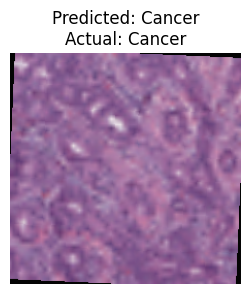

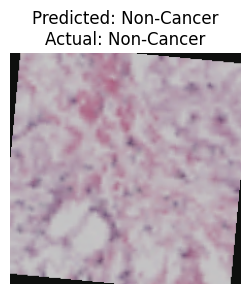

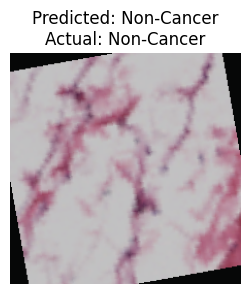

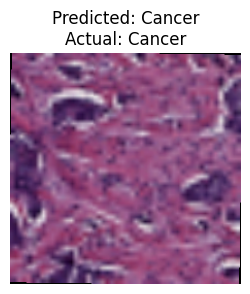

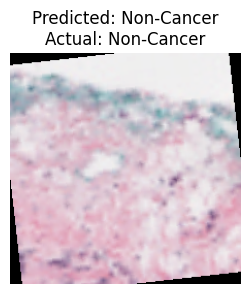

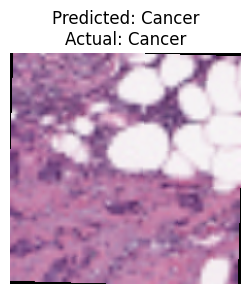

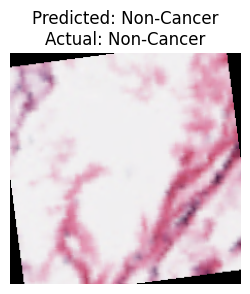

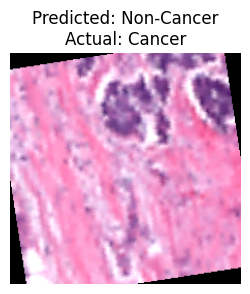

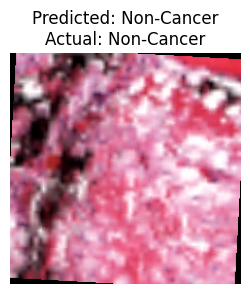

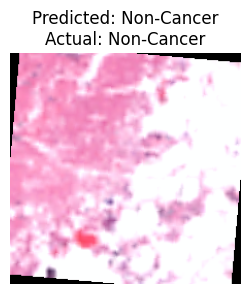

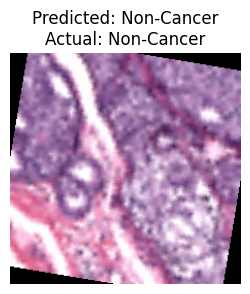

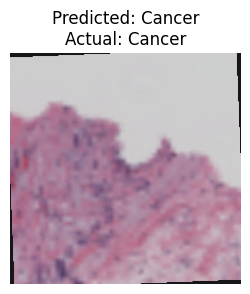

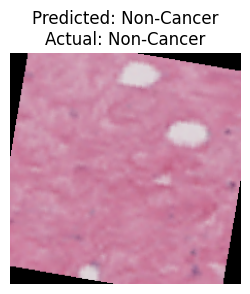

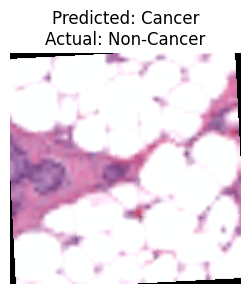

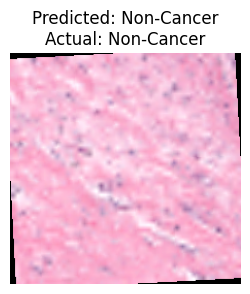

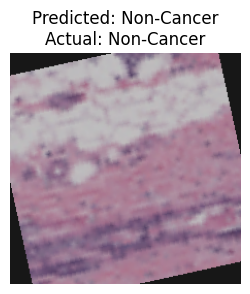

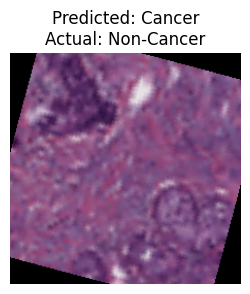

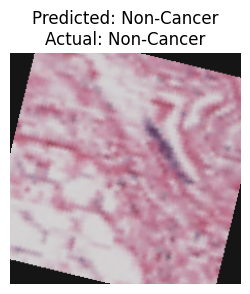

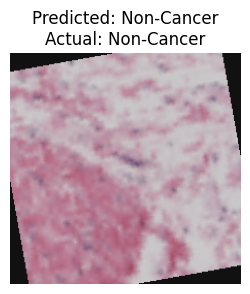

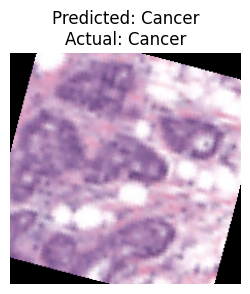

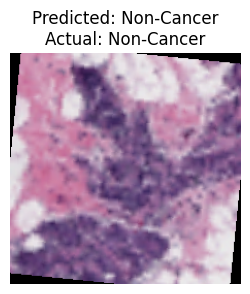

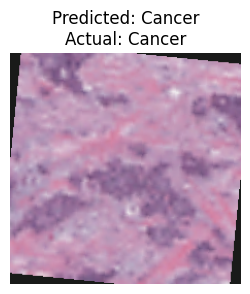

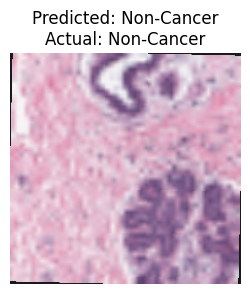

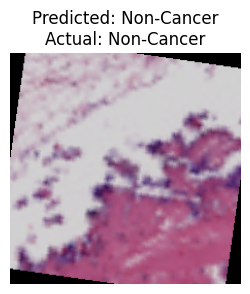

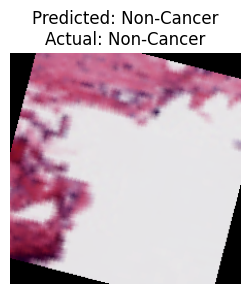

In [ ]:
import matplotlib.pyplot as plt

class_names = ["Non-Cancer", "Cancer"]

model.eval()
shown_images = 0
max_images = 25

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(images)):
            img = images[i].cpu()
            img = img.permute(1, 2, 0).numpy()


            img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img = np.clip(img, 0, 1)

            plt.figure(figsize=(3,3))
            plt.imshow(img)
            plt.title(
                f"Predicted: {class_names[preds[i]]}\n"
                f"Actual: {class_names[labels[i]]}"
            )
            plt.axis("off")
            plt.show()

            shown_images += 1
            if shown_images >= max_images:
                break
        if shown_images >= max_images:
            break

In [ ]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall (Sensitivity):", recall)
print("Specificity:", specificity)
print("F1 Score:", f1)

Accuracy: 0.9168198529411765
Precision: 0.7410526315789474
Recall (Sensitivity): 0.8585365853658536
Specificity: 0.9303510758776897
F1 Score: 0.7954802259887006


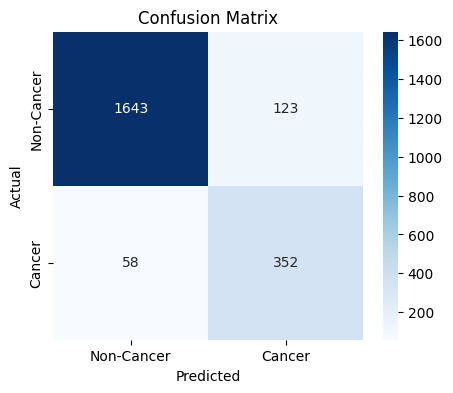

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Cancer", "Cancer"],
            yticklabels=["Non-Cancer", "Cancer"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()